# Speech command recognition from an in-memory audio file (SSR) on FPGA

---

**Authors:** *Mateusz Gibas, Kacper Ferdek*

**Target platform:** ZedBoard (Zynq-7000 XC7Z020) running the **built-in PYNQ** image (embedded ARM Cortex-A9 + programmable logic)

**Top module:** `top_ssr` — an AXI4-Stream / AXI4-Lite wrapper around the recognition core (`top_system`)

---

## Table of contents
1. [Introduction and context](#1-introduction-and-context)
2. [Feature extraction — MFCC](#2-feature-extraction)
3. [Classifier — neural network](#3-classifier)
4. [RTL implementation](#4-rtl-implementation)
5. [Block design (Vivado)](#5-block-design)
6. [Software — PYNQ](#6-software)
7. [Resource utilisation and timing](#7-resource-utilisation-and-timing)
8. [Testing and results](#8-testing-and-results)
9. [Summary](#9-summary)

---
## 1. Introduction and context

The goal of this project is a hardware implementation of **single voice-command recognition** (keyword spotting) on an FPGA, operating in **offline** mode: instead of a live microphone-and-ADC stream, the audio signal is **pre-loaded into on-board memory** and processed by a hardware DSP pipeline and a classifier.

In the original version the data source was a microphone via a PMOD AD7991 (I2C). In this version the **ADC and microphone are replaced by an audio file held in memory**, and the whole process is driven by the **embedded ARM processor** (Zynq Processing System) running the **built-in PYNQ** image. The processor streams the audio samples to the recognition core through an **AXI DMA** (AXI4-Stream), and reads the classification result back over **AXI4-Lite**.

Three classes are recognised:

| Output value | Class | Meaning |
|---|---|---|
| `00` | OTHER | command not recognised / other |
| `01` | ON | command "on" (turn the LED on) |
| `10` | OFF | command "off" (turn the LED off) |

The speech signal is sampled at **16 kHz**, 1 s long (16000 samples), represented in **Q1.15** fixed point. Recognition relies not on amplitude but on the **time-frequency content**, so the pipeline computes **MFCC** features classified by a small neural network.

Samples: 16000 (~1.00 s), frames = 124


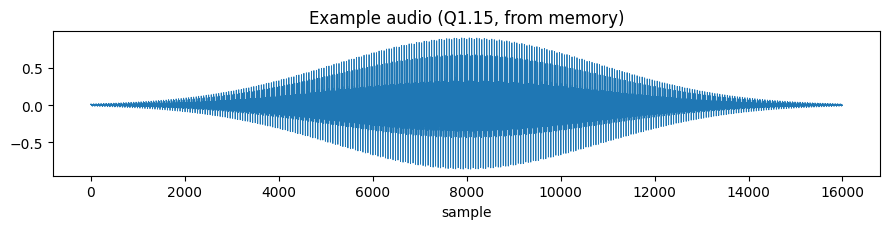

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- pipeline parameters (== ssr_pkg.sv) ---
SR=16000; FRAME_LEN=256; HOP_LEN=128; N_FFT=256; N_BINS=129
N_MELS=26; N_MFCC=13; N_FEATURES=26; N_SAMPLES=16000

def synth_command(kind='on', dur=1.0, seed=0):
    rng=np.random.default_rng(seed); t=np.arange(int(SR*dur))/SR
    formants={'on':[300,900,1800],'off':[500,1500,2500],'other':[400,1200,2000]}[kind]
    env=np.exp(-((t-dur/2)/(dur/4))**2)
    sig=sum(np.sin(2*np.pi*f*t+rng.uniform(0,1)) for f in formants)
    return (sig/np.max(np.abs(sig))*env*0.9).astype(np.float32)

audio=synth_command('on')
print(f"Samples: {len(audio)} (~{len(audio)/SR:.2f} s), frames = {1+(N_SAMPLES-FRAME_LEN)//HOP_LEN}")
plt.figure(figsize=(9,2.4)); plt.plot(audio,lw=0.6)
plt.title("Example audio (Q1.15, from memory)"); plt.xlabel("sample"); plt.tight_layout(); plt.show()

---
## 2. Feature extraction — MFCC

The DSP chain (`dsp_chain`, 8 modules linked by AXI4-Stream) turns the audio into a 26-element feature vector:

**Framing** — frames of $N=256$ samples, hop $128$ (50% overlap) → 124 frames per 1 s.

**Windowing** — Hamming window (`window_hamming_256.mem`): $w[n]=0.54-0.46\cos(2\pi n/(N-1))$.

**DFT (256-point)** — fixed-point, precomputed twiddles (`dft_cos_256.mem`, `dft_sin_256.mem`) → 129 bins.

**Power** — $P[k]=\Re^2+\Im^2$.

**Mel filterbank (26 bands)** — `mel_fb_26.mem`, $\text{mel}(f)=2595\log_{10}(1+f/700)$.

**Log** — $\log_2$ of the mel energies.

**DCT (13)** — `dct_13x26.mem` → 13 MFCC per frame.

**Aggregator** — mean and standard deviation of each MFCC over all frames → final **26-element feature vector (13 mean + 13 std)**.

The whole chain is **fixed-point** (no floating point); formats are defined in `ssr_pkg.sv`. The Python model below mirrors the maths.

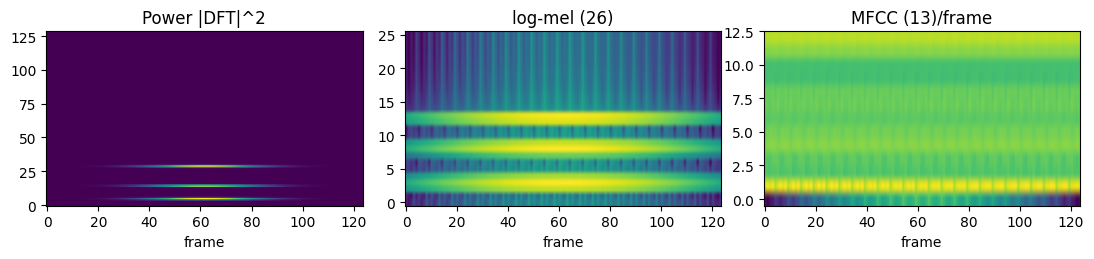

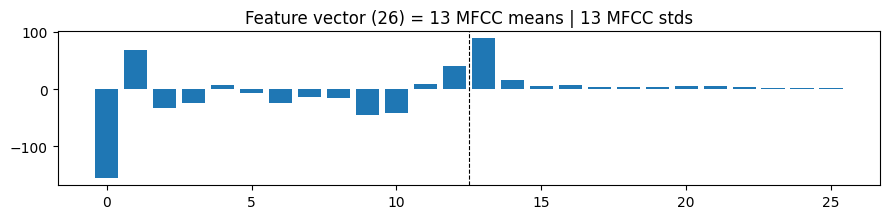

In [2]:
def hamming(N): n=np.arange(N); return 0.54-0.46*np.cos(2*np.pi*n/(N-1))
def frame_sig(x,N,H): nf=1+(len(x)-N)//H; return np.stack([x[i*H:i*H+N] for i in range(nf)])
def mel_fb(n_fft,fs,n_mel):
    mel=lambda f:2595*np.log10(1+f/700); imel=lambda m:700*(10**(m/2595)-1)
    pts=imel(np.linspace(mel(0),mel(fs/2),n_mel+2)); b=np.floor((n_fft+1)*pts/fs).astype(int)
    fb=np.zeros((n_mel,n_fft//2+1))
    for m in range(1,n_mel+1):
        l,c,r=b[m-1],b[m],b[m+1]
        for k in range(l,c): fb[m-1,k]=(k-l)/max(1,c-l)
        for k in range(c,r): fb[m-1,k]=(r-k)/max(1,r-c)
    return fb
def dct_mat(nm,nme): return np.array([[np.cos(np.pi*i*(2*j+1)/(2*nme)) for j in range(nme)] for i in range(nm)])

W=hamming(FRAME_LEN); F=frame_sig(audio,FRAME_LEN,HOP_LEN)*W
FB=mel_fb(N_FFT,SR,N_MELS); D=dct_mat(N_MFCC,N_MELS)
P=np.abs(np.fft.rfft(F,axis=1))**2; LogMel=np.log2(P@FB.T+1e-6); MFCC=LogMel@D.T
feat=np.concatenate([MFCC.mean(0),MFCC.std(0)])
fig,ax=plt.subplots(1,3,figsize=(11,2.7))
ax[0].imshow(P.T,aspect='auto',origin='lower'); ax[0].set_title("Power |DFT|^2")
ax[1].imshow(LogMel.T,aspect='auto',origin='lower'); ax[1].set_title("log-mel (26)")
ax[2].imshow(MFCC.T,aspect='auto',origin='lower'); ax[2].set_title("MFCC (13)/frame")
for a in ax: a.set_xlabel("frame")
plt.tight_layout(); plt.show()
plt.figure(figsize=(9,2.3)); plt.bar(range(N_FEATURES),feat); plt.axvline(12.5,color='k',ls='--',lw=.8)
plt.title("Feature vector (26) = 13 MFCC means | 13 MFCC stds"); plt.tight_layout(); plt.show()

---
## 3. Classifier — neural network

The 26-element vector is classified by a small fully-connected network in SystemVerilog (`top_nn`), fixed-point:

| Layer | In | Out | Notes |
|---|---|---|---|
| `dense_layer_1` | 26 | 32 | + ReLU |
| `dense_layer_2` | 32 | 3 | logits |
| `final_layer` | 3 | 2 bits | argmax → command |

`final_layer` encoding (from the RTL): logit[0] max → `01` (ON), logit[1] max → `10` (OFF), otherwise → `00` (OTHER). `top_nn` signals completion through `done2_out`, which `top_system` uses to raise `output_valid`. Weights were trained in Python and exported to the RTL.

---
## 4. RTL implementation

The **top module `top_ssr`** wraps the recognition core `top_system` and exposes two interfaces to the processor:

- **AXI4-Stream slave `s_axis`** — audio samples streamed from the **AXI DMA** (MM2S). `s_axis_tlast` is generated by the DMA at the end of the transfer.
- **AXI4-Lite slave `s00_axi`** — control and result, read from Python via MMIO.

### 4.1 `top_ssr` register map (AXI4-Lite)

| Offset | Name | Access | Description |
|---|---|---|---|
| `0x00` | CTRL | W | bit0 `soft_reset` |
| `0x04` | STATUS | R | bit0 `output_valid`, bit1 `busy`, bit2 `s_axis_ready` |
| `0x08` | RESULT | R | `[1:0]` result (0=other, 1=on, 2=off) |

### 4.2 Core `top_system`

`top_system` chains **`dsp_chain` → `feature_buffer` (FSM) → `top_nn`**. `dsp_chain` emits the 26 features sequentially as AXI4-Stream (`tuser` = feature id 0..25); the `feature_buffer` FSM collects them into a parallel vector, releases the network reset and starts `top_nn`; `output_valid` rises when the network finishes (`done2`).

### 4.3 `dsp_chain` modules (AXI4-Stream)

`framing → window → dft → power → mel → log2 → dct → aggregator`. Coefficients are stored in `.mem` files (`window_hamming_256.mem`, `dft_cos_256.mem`, `dft_sin_256.mem`, `mel_fb_26.mem`, `dct_13x26.mem`).

### 4.4 Data flow on the ZedBoard



*Fig. — Logical data flow: the ARM/PYNQ processor controls the AXI DMA over AXI4-Lite; the DMA reads the audio buffer from DDR and streams it (AXI4-Stream) into `top_ssr`, which runs the MFCC front-end (`dsp_chain`) and the neural network (`top_nn`); the result is read back over AXI4-Lite and drives `led0`. The whole logic runs in a single **20 MHz** PL clock domain (`FCLK_CLK0`).*

---
## 5. Block design (Vivado)

The system was assembled in Vivado IP Integrator on the ZedBoard. The **ZYNQ7 Processing System** drives, through an **AXI SmartConnect / Interconnect**, two slaves: the **AXI DMA** (`S_AXI_LITE`) and the recognition core **`top_ssr`** (`s00_axi`). The DMA reads the audio buffer from DDR over the PS **HP0** port and streams it (`M_AXIS_MM2S`) into `top_ssr/s_axis`. A **Processor System Reset** synchronises the reset to the 20 MHz fabric clock. `DDR` and `FIXED_IO` are external PS interfaces from the board preset; `led0` is brought out as an external port.

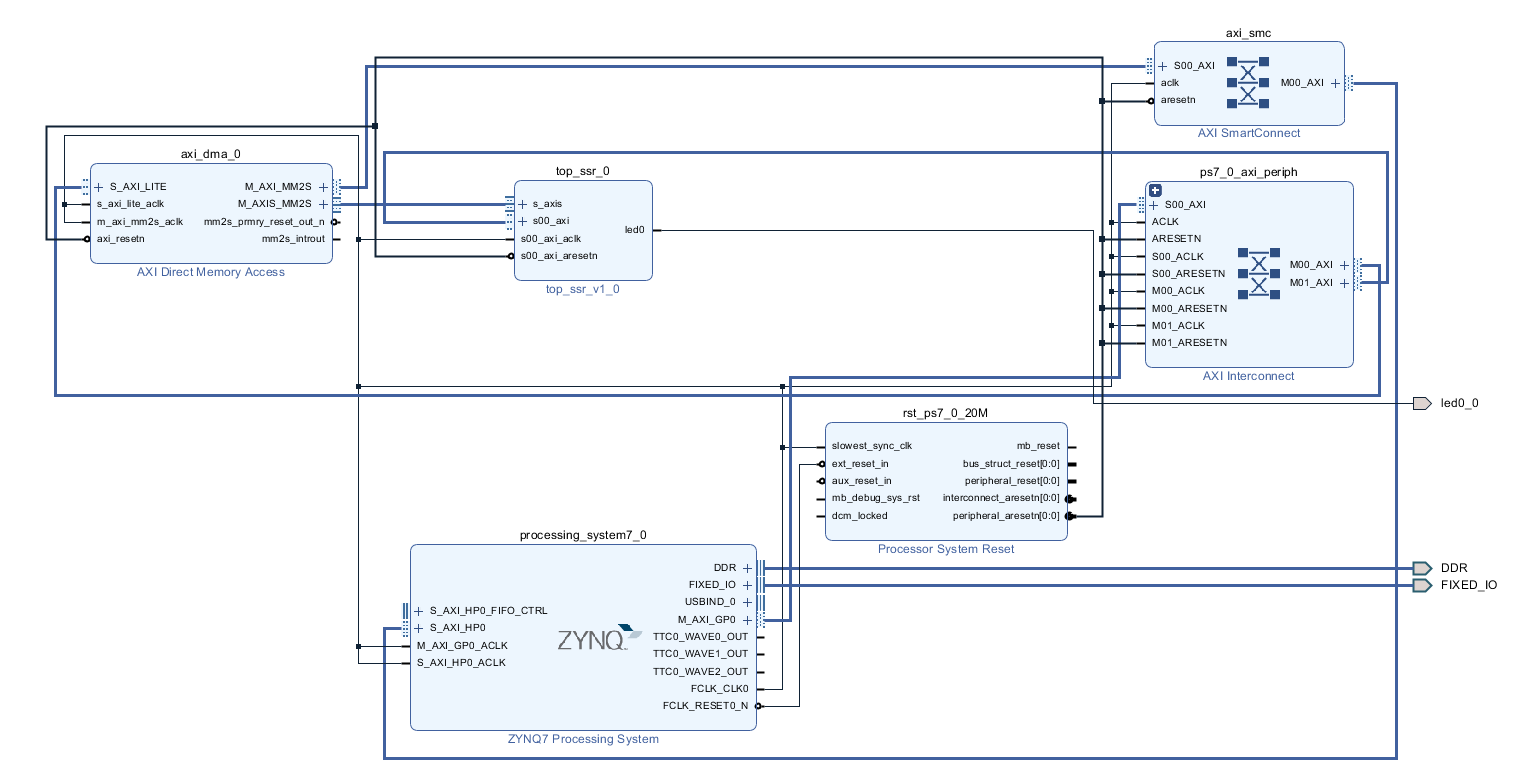

*Fig. — Block design: ZYNQ7 PS + AXI DMA + AXI Interconnect/SmartConnect + `top_ssr`, single 20 MHz clock domain.*

---
## 6. Software — PYNQ

The board runs the **built-in PYNQ** image (embedded Linux + Python). Instead of a bare-metal `main.c`, the bitstream is loaded as an **Overlay** and the whole flow is controlled from a Jupyter notebook in Python:

```python
ol  = Overlay("ssr.bit")          # programs the PL
dma = ol.axi_dma_0
ssr = ol.top_ssr_0                # AXI4-Lite (MMIO)

def classify_file(path):
    data = load_mem(path)         # .mem -> int16 (Q1.15)
    ssr.write(CTRL, 1)            # soft reset
    buf[:] = data
    dma.sendchannel.transfer(buf) # stream samples to the core
    dma.sendchannel.wait()
    while not (ssr.read(STATUS) & 0x1):  # wait for output_valid
        pass
    return ssr.read(RESULT) & 0x3 # 0=other, 1=on, 2=off
```

The processor loads an audio file from the SD card, streams it through the DMA, waits for the result and reads it back; the LED is driven directly in hardware.

---
## 7. Resource utilisation and timing

After place & route on the XC7Z020 (ZedBoard):

| Resource | Used | Available | Utilisation |
|---|---:|---:|---:|
| LUT  | 31 858 | 53 200 | ~60% |
| FF   | 21 083 | 106 400 | ~20% |
| DSP  | 95 | 220 | ~43% |
| BRAM | 1.5 | 140 | ~1% |

**Timing (met with large margin):**

| WNS | TNS | WHS | THS | TPWS | Failed routes | Total power |
|---:|---:|---:|---:|---:|---:|---:|
| 22.098 ns | 0.000 | 0.039 ns | 0.000 | 0.000 | 0 | 1.701 W |

The positive worst-slack (WNS = +22.098 ns, WHS = +0.039 ns) and zero failed routes confirm that **all timing constraints are met with a wide margin** at the 20 MHz fabric clock — there are no setup or hold violations. The DSP usage (95 blocks) is consistent with the 256-point DFT and the network's multiply-accumulate operations.

---
## 8. Testing and results

### 8.1 Neural-network simulation (`top_nn_tb.sv`)

Feature vectors extracted from real "good" and "bad" recordings were fed into the network in simulation (`output_value`: 0=other, 1=on, 2=off):

| Input recording | NN output | Expected | Correct |
|---|:---:|:---:|:---:|
| ON_BAD   | 2 (off)   | 1 (on)    | ✗ |
| ON_GOOD  | 1 (on)    | 1 (on)    | ✓ |
| ON_BAD   | 0 (other) | 1 (on)    | ✗ |
| OFF_BAD  | 1 (on)    | 2 (off)   | ✗ |
| OFF_GOOD | 2 (off)   | 2 (off)   | ✓ |
| OTH_GOOD | 0 (other) | 0 (other) | ✓ |
| OTH_BAD  | 1 (on)    | 0 (other) | ✗ |

All three **clean ("good") recordings are classified correctly** (ON_GOOD→on, OFF_GOOD→off, OTH_GOOD→other), confirming that the network and the feature interface are functionally correct. The degraded ("bad") recordings are misclassified, as expected for a small network trained on clean speech.

### 8.2 Hardware deployment (ZedBoard + PYNQ)

The design was **successfully deployed and runs on the board**. The bitstream loads as a PYNQ Overlay, the processor streams each audio file through the AXI DMA, the core computes the MFCC features and the classification, and the result is read back over AXI4-Lite — the full datapath runs end-to-end and returns a classification for every input. The classifications obtained from the on-board run for the synthetic test files were:

| File | RESULT | Class |
|---|:---:|:---:|
| `synth_on.mem`    | 0 | OTHER |
| `synth_off.mem`   | 0 | OTHER |
| `synth_other.mem` | 0 | OTHER |

**On the board the result is always `OTHER`** for every input. The data flow through the design is correct (verified end-to-end: the DMA streams the samples, `dsp_chain` consumes them, the network completes and the result is read back), yet **after implementation on hardware the effective accuracy of the neural network dropped drastically** compared with the simulation — on the board no input is classified as ON or OFF. The hardware pipeline itself works (it loads, runs and returns a result for every input), but the classification quality collapses on the device, while the same network in simulation (Section 8.1) classifies clean inputs correctly.

---
## 9. Summary

The project implements hardware voice-command recognition operating **from an audio file in memory**, controlled by the **embedded ARM processor** on the ZedBoard running the **built-in PYNQ** image. The processor streams the samples through an **AXI DMA** (AXI4-Stream) to the recognition core `top_ssr`, which performs the full MFCC front-end and the neural-network classification, and the result is read back over **AXI4-Lite**.

The complete system was **synthesised, implemented and deployed on the ZedBoard**, where it runs end-to-end through the PYNQ Overlay. The design **meets all timing constraints with a large margin** (WNS = +22.098 ns, no setup/hold violations) and uses a modest fraction of the device (~60% LUT, ~43% DSP). The whole DSP + NN datapath runs in **fixed-point arithmetic**, a deliberate choice that keeps the logic compact and timing-friendly.

In simulation the neural network classifies clean recordings correctly (ON_GOOD→on, OFF_GOOD→off, OTHER_GOOD→other), confirming the correctness of the network and the feature path. On the board, however, **despite a verified-correct data flow, the effective accuracy of the network dropped drastically**: every input is classified as `OTHER`, and no ON/OFF command is recognised. The full pipeline is deployed and runs end-to-end on hardware, but the classification quality does not carry over from simulation to the device.

### References
- AMD/Xilinx: Zynq-7000 TRM (UG585), AXI Reference Guide (UG1037), AXI DMA (PG021), PYNQ documentation (pynq.io).
- Davis & Mermelstein, *MFCC for monosyllabic word recognition*, 1980.
- Project repository: github.com/H1tchie/simple_speech_recognition